<a href="https://colab.research.google.com/github/ferminestrad/Simulacion/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simulación del peso total transportado por el camión de TIBASA**
1. Planteamiento del problema
La empresa TIBASA transporta diariamente 5 tinas de baño en un camión.
El peso de cada tina sigue una distribución triangular con:

mínimo: a = 190 kg

moda: c = 210 kg

máximo: b = 230 kg


La capacidad del camión es de:

1000 kg (1 tonelada)

Se desea estimar mediante simulación:

$P(X1 + X2 + X3 + X4 + X5 > 1000)$



In [1]:
import numpy as np
import matplotlib.pyplot as plt

**La metodología de simulación tiene dos partes:**

Generar valores aleatorios con la distribución triangular del peso de una tina.
Repetir el experimento muchas veces para estimar la probabilidad pedida como una proporción de eventos favorables.

In [2]:
def triangular(n):
    muestras = []
    for _ in range(n):
        u = np.random.rand()
        if u < 0.5:
            x = 190 + 20 * np.sqrt(2 * u)
        else:
            x = 230 - 20 * np.sqrt(2 * (1 - u))
        muestras.append(x)
    return np.array(muestras)

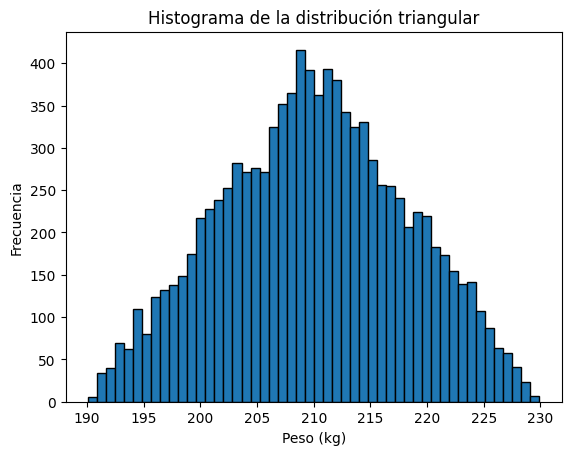

In [3]:
m = triangular(10000)

plt.hist(m, bins=50, edgecolor='black')
plt.title("Histograma de la distribución triangular")
plt.xlabel("Peso (kg)")
plt.ylabel("Frecuencia")
plt.show()

In [4]:
def simular_dias(N):
    totales = []
    for _ in range(N):
        pesos = triangular(5)
        totales.append(np.sum(pesos))
    return np.array(totales)

N = 100000
totales = simular_dias(N)

probabilidad = np.mean(totales > 1000)
print("Probabilidad estimada:", probabilidad)

Probabilidad estimada: 0.99749


Al ejecutar la simulación con un número grande de repeticiones, el valor estimado de la probabilidad debe ser cercano a:


$P(X1 + X2 + X3 + X4 + X5 > 1000) = 0.99749$

 Esto indica que el camión prácticamente siempre transporta más peso del permitido.